In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [4]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [5]:
df.head(3)

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260


In [6]:
df.describe()

,year,fertility_rate_hist
count,19402.000000,19402.000000
mean,1985.861612,3.936123
std,22.049134,1.991179
min,1891.000000,0.662000
25%,1967.000000,2.138210
50%,1986.000000,3.466000
75%,2005.000000,5.849000
max,2023.000000,8.864000


In [7]:
df.shape

(19402, 4)

In [8]:
df.columns.tolist()

['entity', 'code', 'year', 'fertility_rate_hist']

In [9]:
mexico = df[df["entity"]=="Mexico"]

In [10]:
type(mexico)

pandas.DataFrame

In [11]:
mexico.head()

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745


In [12]:
japon = df[df["entity"]=="Japan"]

In [13]:
japon.head()

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373
8387,Japan,JPN,1950,3.615
8388,Japan,JPN,1951,3.225


In [14]:
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()

In [15]:
type(anios_mexico)

numpy.ndarray

In [16]:
promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)
minimo_mexico = np.min(tasa_mexico)
desviacion_mexico = np.std(tasa_mexico)

print("Promedio México:", promedio_mexico)
print("Máximo México:", maximo_mexico)
print("Mínimo México:",minimo_mexico)
print("Desviación estándar México:",desviacion_mexico)



Promedio México: 4.326364864864865
Máximo México: 6.833
Mínimo México: 1.91
Desviación estándar México: 1.8802504834162772


In [17]:
promedio_japon = np.mean(tasa_japon)
maximo_japon = np.max(tasa_japon)
minimo_japon = np.min(tasa_japon)
desviacion_japon = np.std(tasa_japon)

print("Promedio Japón:", promedio_japon)
print("Máximo Japón:", maximo_japon)
print("Mínimo Japón:",minimo_japon)
print("Desviación estándar Japón:",desviacion_japon)

Promedio Japón: 1.8388051948051947
Máximo Japón: 4.614
Mínimo Japón: 1.208
Desviación estándar Japón: 0.7018619770141482


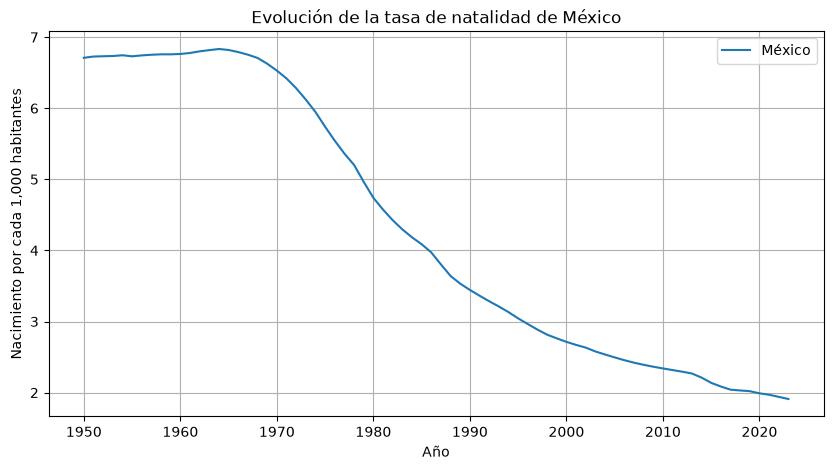

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.title("Evolución de la tasa de natalidad de México")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

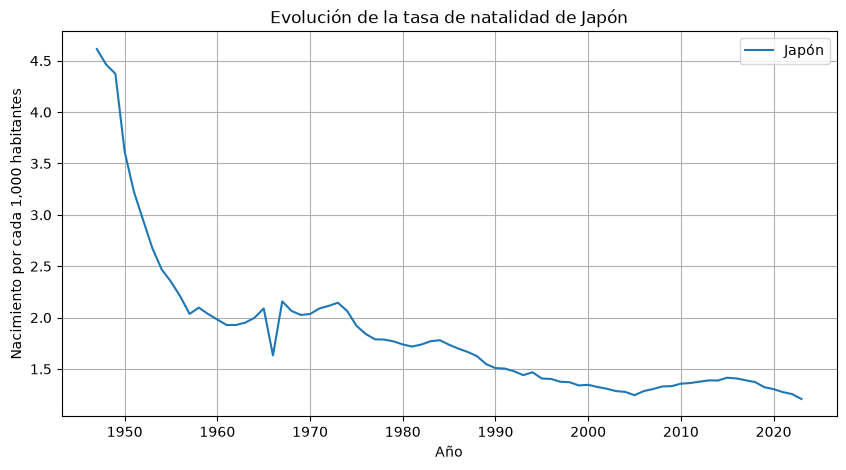

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)

plt.title("Evolución de la tasa de natalidad de Japón")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

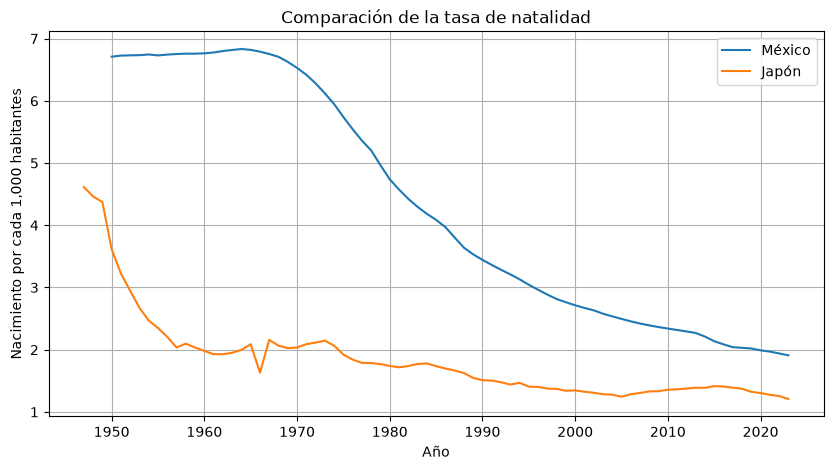

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)

plt.title("Comparación de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [21]:
mexico.shape

(74, 4)

In [22]:
japon.shape

(77, 4)

In [23]:
diferencia = tasa_mexico - tasa_japon 
#sale error porque mexico y japon no tienen la misma cantidad de datos, por lo tanto no pueden hacer operaciones juntas --> operands could not 
# be broadcast together with shapes (74,) (77,) 
#para que funcione tiene que tener la misma cantidad de vectores

ValueError: operands could not be broadcast together with shapes (74,) (77,) 

In [ ]:
filtro_coinicendia_anios = anios_japon >= anios_mexico.min()

In [ ]:
filtro_coinicendia_anios.shape

(77,)

In [ ]:
filtro_coinicendia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [ ]:
anios_japon = anios_japon[filtro_coinicendia_anios]

In [ ]:
anios_japon.shape

(74,)

In [ ]:
anios_japon

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [ ]:
tasa_japon.shape

(74,)

In [ ]:
tasa_mexico.shape

(74,)

In [ ]:
diferencia_mx_jp = tasa_mexico - tasa_japon

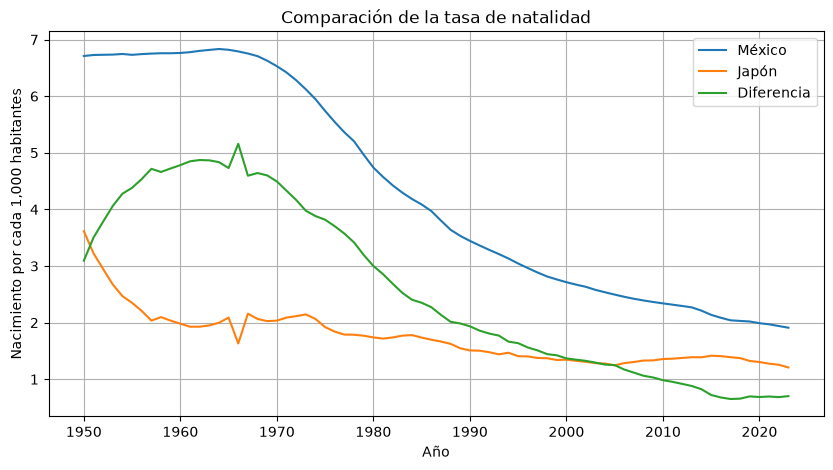

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)

plt.plot(
    anios_mexico,
    diferencia_mx_jp,
    label="Diferencia"
)

plt.title("Comparación de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [ ]:
#Ahora vamos a hacer la diferencia entre Mexico y Brazil
brazil = df[df["entity"]=="Brazil"]

In [ ]:
brazil.head()

,entity,code,year,fertility_rate_hist
2371,Brazil,BRA,1950,6.122
2372,Brazil,BRA,1951,6.115
2373,Brazil,BRA,1952,6.102
2374,Brazil,BRA,1953,6.093
2375,Brazil,BRA,1954,6.087


In [ ]:
brazil.shape

(74, 4)

In [ ]:
mexico.shape

(74, 4)

In [ ]:
anios_brazil = brazil["year"].to_numpy()
tasa_brazil = brazil["fertility_rate_hist"].to_numpy()

In [ ]:
tasa_brazil.shape

(74,)

In [ ]:
diferencia_mx_bz = tasa_mexico - tasa_brazil

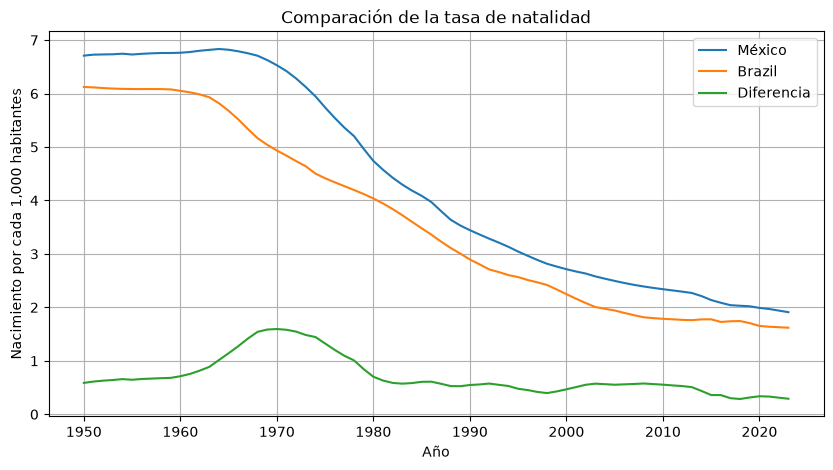

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.plot(
    anios_brazil,
    tasa_brazil,
    label="Brazil"
)

plt.plot(
    anios_mexico,
    diferencia_mx_bz,
    label="Diferencia"
)

plt.title("Comparación de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [35]:
#Otra forma de encontrar considencias entre dos arreglos 
anios_comunes = np.intersect1d(
    anios_mexico,
    anios_japon
)

In [27]:
anios_comunes

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [ ]:
#Otra forma de extraer los datos, es prepararlos desde el data frame de pandas 
#Ahora usaremos una funcion llamada merge()

In [ ]:
comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japon[["year", "fertility_rate_hist"]],
    on = "year",
    suffixes=("_mexico","_japon")
)

In [ ]:
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947


In [28]:
mexico_anios_comunes = mexico[mexico["year"].isin(anios_comunes)]
japon_anios_comunes = japon[japon["year"].isin(anios_comunes)]

In [30]:
mexico_tasa_comunes = mexico[mexico["fertility_rate_hist"].isin(anios_comunes)]
japon_tasa_comunes = japon[japon["fertility_rate_hist"].isin(anios_comunes)]

In [ ]:
mex_anios_comunes = mexico_anios_comunes["year"].to_numpy() #se convierten a numpy para poder graficar
jpn_anios_comunes = japon_anios_comunes["year"].to_numpy()

In [41]:
mex_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].to_numpy()
jpn_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].to_numpy()

In [36]:
japon_anios_comunes.shape

(0, 4)

In [32]:
mexico_anios_comunes.shape

(0, 4)

In [33]:
anios_japon = np.delete(anios_japon, [23,25,30,42,48])

In [37]:
len(anios_comunes)

69